In [10]:
import cv2
import numpy as np
from ultralytics import YOLO
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
model = YOLO("yolo26m.pt")

train_results = model.train(
    data="dataset.yaml",
    epochs=200,
    imgsz=1280,
    # device="cpu",  # Device to run on (e.g., 'cpu', 0, [0,1,2,3])
    device=[0],  # Device to run on (e.g., 'cpu', 0, [0,1,2,3])
    # lr0=0.001,
    batch=4
)

In [ ]:
metrics = model.val()

In [7]:
model = YOLO("runs/detect/train-8/weights/best.pt")
results = model("yolo_tiled/images/08a9d36e-page1_6.png") # conf=0.005
# results[0].show(labels=False, conf=False)

# Export the model to ONNX format for deployment
# path = model.export(format="onnx")  # Returns the path to the exported model


image 1/1 /Users/ihpar/Documents/Deve/omr/yolo_tiled/images/08a9d36e-page1_6.png: 1280x1280 2 barlines, 5 comma_4_downs, 12 comma_4_ups, 3 notehead_emptys, 45 notehead_filleds, 3 rests, 7 treble_clefs, 1168.9ms
Speed: 4.7ms preprocess, 1168.9ms inference, 0.1ms postprocess per image at shape (1, 3, 1280, 1280)


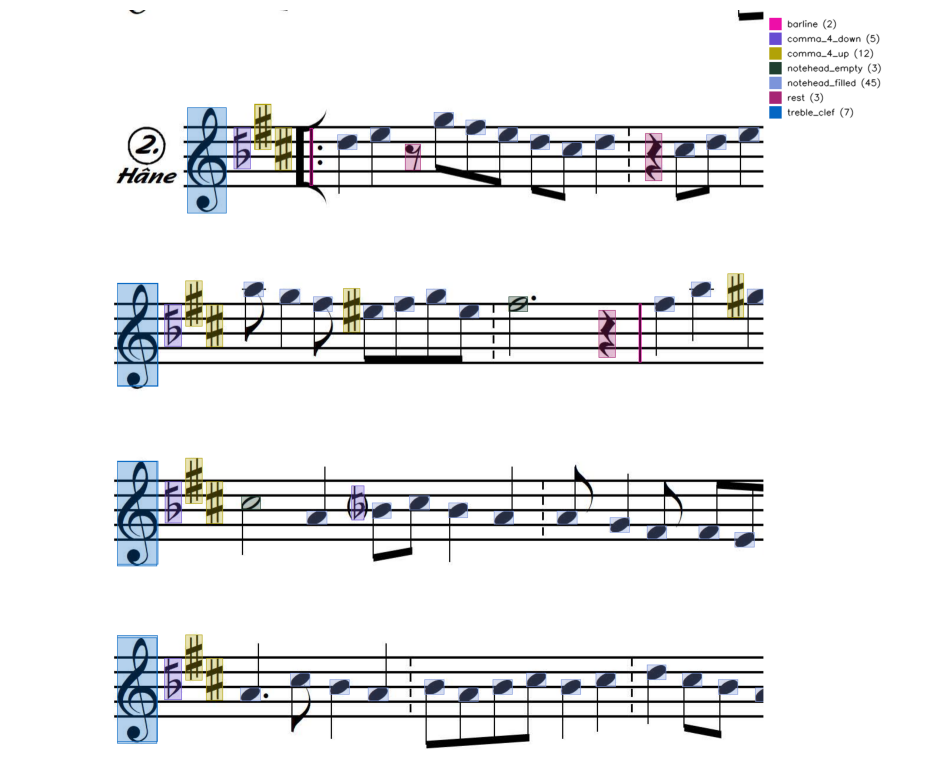

In [19]:
res = results[0]
img = res.orig_img.copy()

# -----------------------------
# Class names (your YAML order)
# -----------------------------

CLASS_NAMES = [
    "barline",
    "comma_1_down",
    "comma_4_down",
    "comma_4_up",
    "natural",
    "notehead_empty",
    "notehead_filled",
    "rest",
    "treble_clef"
]

# -----------------------------
# Color map (fixed per class)
# -----------------------------

np.random.seed(2)
COLORS = np.random.randint(0, 255, size=(len(CLASS_NAMES), 3))

# -----------------------------
# Count present classes
# -----------------------------

class_ids = [int(b.cls[0]) for b in res.boxes]
counts = Counter(class_ids)
present_classes = sorted(counts.keys())

# -----------------------------
# Draw transparent overlays
# -----------------------------

overlay = img.copy()
alpha = 0.3  # transparency level

for box in res.boxes:
    cls = int(box.cls[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    color = tuple(map(int, COLORS[cls]))

    # Filled transparent rectangle
    cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)

    # Thin border on original image
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 1)

# Blend overlay with original
img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

# -----------------------------
# Create legend (only present classes)
# -----------------------------

legend_width = 300
legend = np.ones((img.shape[0], legend_width, 3), dtype=np.uint8) * 255

y_offset = 30

for cls in present_classes:
    name = CLASS_NAMES[cls]
    color = tuple(map(int, COLORS[cls]))
    count = counts[cls]

    # Color box
    cv2.rectangle(
        legend,
        (10, y_offset - 15),
        (30, y_offset + 5),
        color,
        -1
    )

    # Text with count
    cv2.putText(
        legend,
        f"{name} ({count})",
        (40, y_offset),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 0),
        1,
        cv2.LINE_AA
    )

    y_offset += 25

# -----------------------------
# Combine image + legend
# -----------------------------

combined = np.hstack((img, legend))


img_rgb = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [18]:
COLORS

array([[ 37, 235, 140],
       [ 72, 137, 203],
       [133,  79, 192],
       [144, 129, 204],
       [ 71, 237, 252],
       [134,  25, 178],
       [ 20, 254, 101],
       [146, 212, 139],
       [252, 234, 156]])